# Campaign comparison — 2P5E peptide design continuity

Same analysis blocks applied across **every campaign**, so we can see how the design profile shifts
as constraints/context change:

| Campaign | context | constraints | L |
|---|---|---|---|
| full_50K | A+B+D+E | with Met, with Pro | 9 |
| MHC_only | A+B | with Met, with Pro | 9 |
| 100K_7T | A+B+D+E | **no Met@P1, no Pro**, 7 temps | 9 |
| relax_ens | A+B+D+E, **12 conformations** | **no Met@P1, no Pro** | 9 |

Plus sections for the **RFdiffusion 8–11mers** and the **22-structure recovery panel**.
Robust to in-progress jobs — re-run anytime.

In [1]:
from pathlib import Path
import re, glob, warnings, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
try: from IPython.display import display
except Exception: display=print
warnings.filterwarnings("ignore"); sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110
ROOT=Path("/home/ubuntu/if-mhc"); NATIVE="SLLMWITQC"; L=len(NATIVE); ANCHORS=[2,9]
AA=list("ACDEFGHIKLMNPQRSTVWY"); AA_IDX={a:i for i,a in enumerate(AA)}
FIG=ROOT/"outputs/analysis/figures"; FIG.mkdir(parents=True,exist_ok=True)

def load_fasta(path):
    rows=[]; p=Path(path)
    if not p.exists(): return rows
    ls=p.read_text().splitlines()
    for i in range(0,len(ls)-1,2):
        h,s=ls[i],ls[i+1].strip()
        if "sample=" not in h: continue
        d=dict(re.findall(r'(\w+)=([-\d.]+)',h))
        rows.append({"peptide":s,"score":float(d.get("score","nan")),"T":float(d.get("T","nan"))})
    return rows
def load_many(paths):
    r=[]
    for p in paths: r+=load_fasta(p)
    return r
def freq_matrix(seqs,Ln):
    M=np.zeros((Ln,len(AA)))
    for s in seqs:
        for i,c in enumerate(s):
            if i<Ln and c in AA_IDX: M[i,AA_IDX[c]]+=1
    M/=np.clip(M.sum(1,keepdims=True),1,None)
    return pd.DataFrame(M,columns=AA,index=list(range(Ln)))

# campaign registry (label -> list of fasta paths)
CAMP={
 "full_50K\n(M,P)":      [ROOT/"outputs/mpnn_50k/seqs/2P5E.fa"],
 "MHC_only\n(M,P)":      [ROOT/"outputs/mpnn_mhconly_v20/seqs/2P5E_ABC.fa"],
 "100K_7T\n(noM,noP)":   [ROOT/"outputs/mpnn_100k_7temp/seqs/2P5E.fa"],
 "relax_ens\n(noM,noP)": list(map(str,(ROOT/"outputs/relax_campaign/seqs").glob("*.fa"))),
}
C={}
for lab,paths in CAMP.items():
    seqs=[r["peptide"] for r in load_many(paths) if len(r["peptide"])==L]
    if seqs: C[lab]=seqs
labels=list(C.keys())
print("campaigns loaded:", {k.replace(chr(10),' '):len(v) for k,v in C.items()})

campaigns loaded: {'full_50K (M,P)': 50028, 'MHC_only (M,P)': 50048, '100K_7T (noM,noP)': 100128, 'relax_ens (noM,noP)': 24000}


## 1. Continuity inventory

In [2]:
nat=np.array(list(NATIVE)); rows=[]
for lab,seqs in C.items():
    P=np.array([list(s) for s in seqs]); ident=(P==nat).mean(1)*100
    rows.append({"campaign":lab.replace(chr(10),' '),"n":len(seqs),"unique":len(set(seqs)),
        "%Met@P1":round(100*np.mean([s[0]=='M' for s in seqs]),1),
        "%has_Pro":round(100*np.mean(['P' in s for s in seqs]),1),
        "mean_id%":round(ident.mean(),1),"max_id%":round(ident.max(),1),
        "exact":int((ident==100).sum())})
display(pd.DataFrame(rows))

,campaign,n,unique,%Met@P1,%has_Pro,mean_id%,max_id%,exact
0,"full_50K (M,P)",50028,3413,96.5,99.7,32.1,66.7,0
1,"MHC_only (M,P)",50048,10621,94.3,99.7,10.6,33.3,0
2,"100K_7T (noM,noP)",100128,38685,0.0,0.0,37.5,77.8,0
3,"relax_ens (noM,noP)",24000,15962,0.0,0.0,21.9,66.7,0


## 2. Per-position frequency — one panel per campaign (AA × position, native boxed)

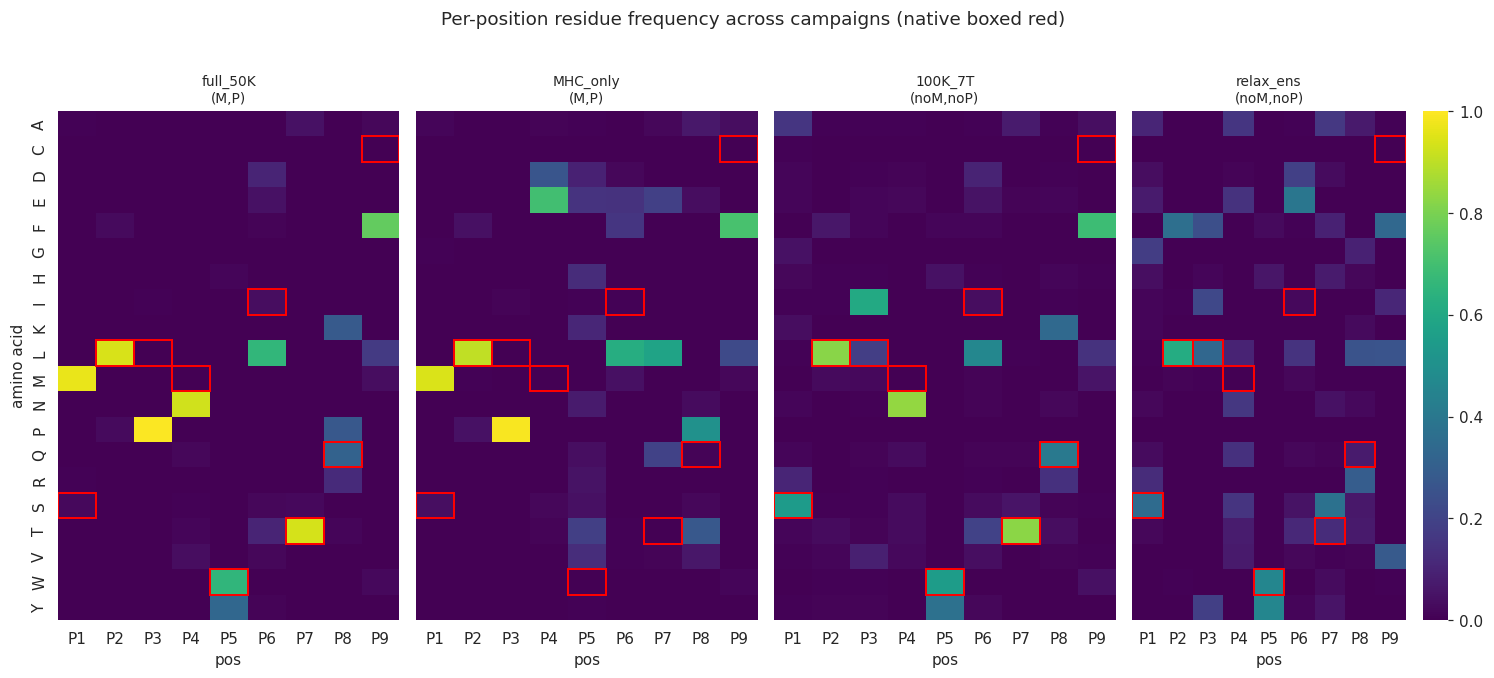

In [3]:
n=len(labels); fig,axes=plt.subplots(1,n,figsize=(3.2*n+1,6),squeeze=False); axes=axes[0]
for ax,lab in zip(axes,labels):
    f=freq_matrix(C[lab],L)
    last=(lab==labels[-1])
    sns.heatmap(f.T,cmap="viridis",vmin=0,vmax=1,ax=ax,cbar=last,
                xticklabels=[f"P{i+1}" for i in range(L)],yticklabels=(AA if lab==labels[0] else False))
    for i,c in enumerate(NATIVE):
        if c in AA_IDX: ax.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=1.3))
    ax.set_title(lab,fontsize=9); ax.set_xlabel("pos")
axes[0].set_ylabel("amino acid")
plt.suptitle("Per-position residue frequency across campaigns (native boxed red)",y=1.02)
plt.tight_layout(); plt.savefig(FIG/"cmp_freq.png",bbox_inches="tight"); plt.show()

## 3. Sequence logos (bits) — one per campaign

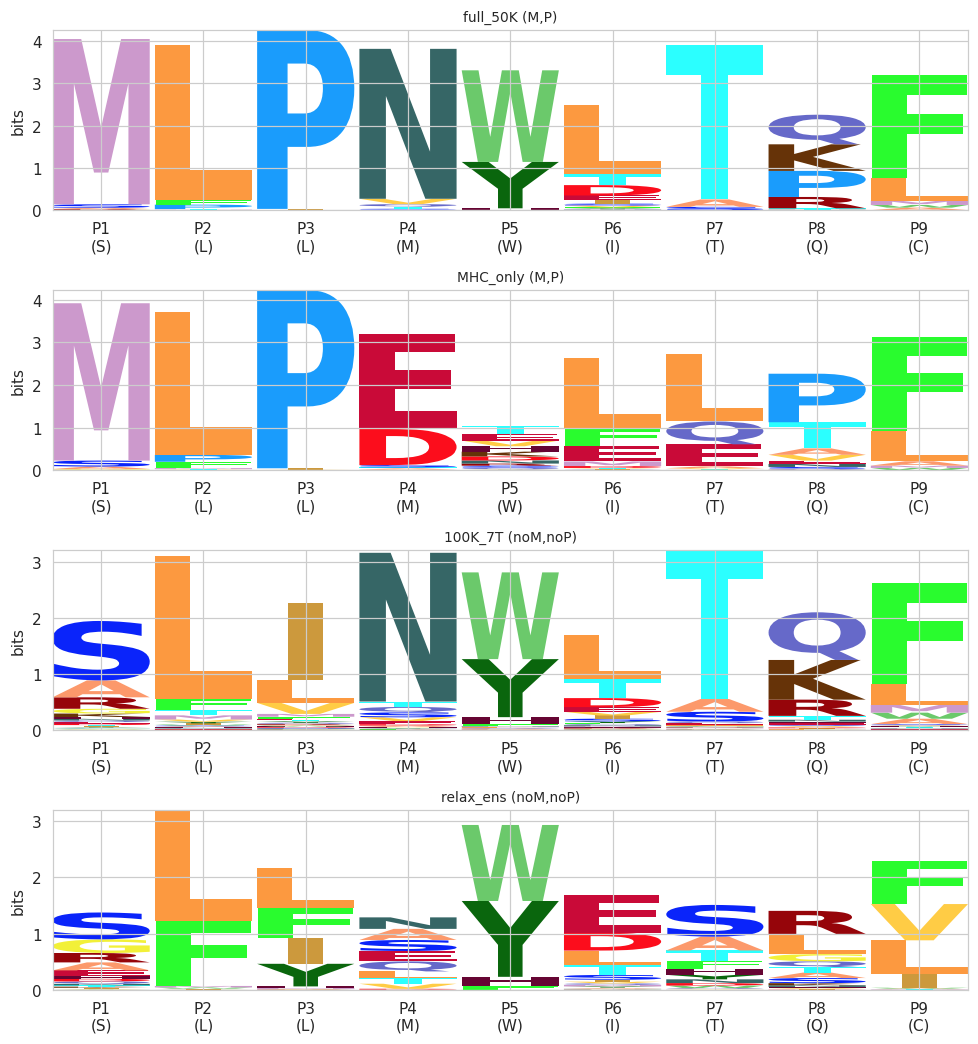

In [4]:
import logomaker
fig,axes=plt.subplots(n,1,figsize=(max(7,L),2.4*n),squeeze=False); axes=axes[:,0]
for ax,lab in zip(axes,labels):
    f=freq_matrix(C[lab],L)
    info=logomaker.transform_matrix(f.copy(),from_type="probability",to_type="information")
    logomaker.Logo(info,ax=ax,color_scheme="skylign_protein")
    ax.set_title(lab.replace(chr(10),' '),fontsize=9); ax.set_ylabel("bits")
    ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}\n({NATIVE[i]})" for i in range(L)])
plt.tight_layout(); plt.savefig(FIG/"cmp_logos.png",bbox_inches="tight"); plt.show()

## 4. Per-position native recovery — grouped across campaigns

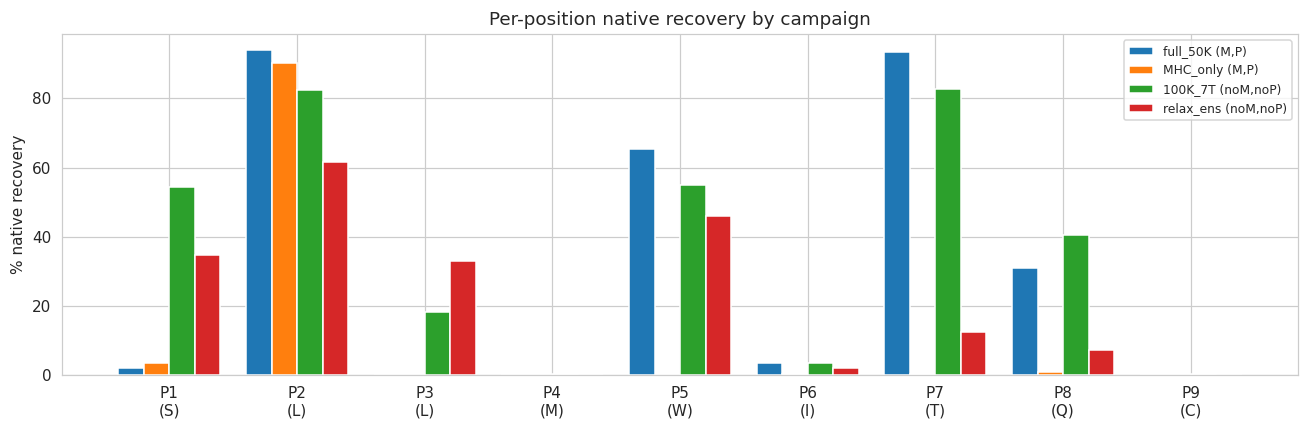

In [5]:
x=np.arange(L); w=0.8/max(1,n)
fig,ax=plt.subplots(figsize=(12,4))
for k,lab in enumerate(labels):
    P=np.array([list(s) for s in C[lab]]); rec=(P==nat).mean(0)*100
    ax.bar(x+(k-(n-1)/2)*w,rec,w,label=lab.replace(chr(10),' '))
ax.set_xticks(x); ax.set_xticklabels([f"P{i+1}\n({NATIVE[i]})" for i in range(L)])
ax.set_ylabel("% native recovery"); ax.legend(fontsize=8); ax.set_title("Per-position native recovery by campaign")
plt.tight_layout(); plt.savefig(FIG/"cmp_recovery.png",bbox_inches="tight"); plt.show()

## 5. Identity-to-native distributions + per-position entropy

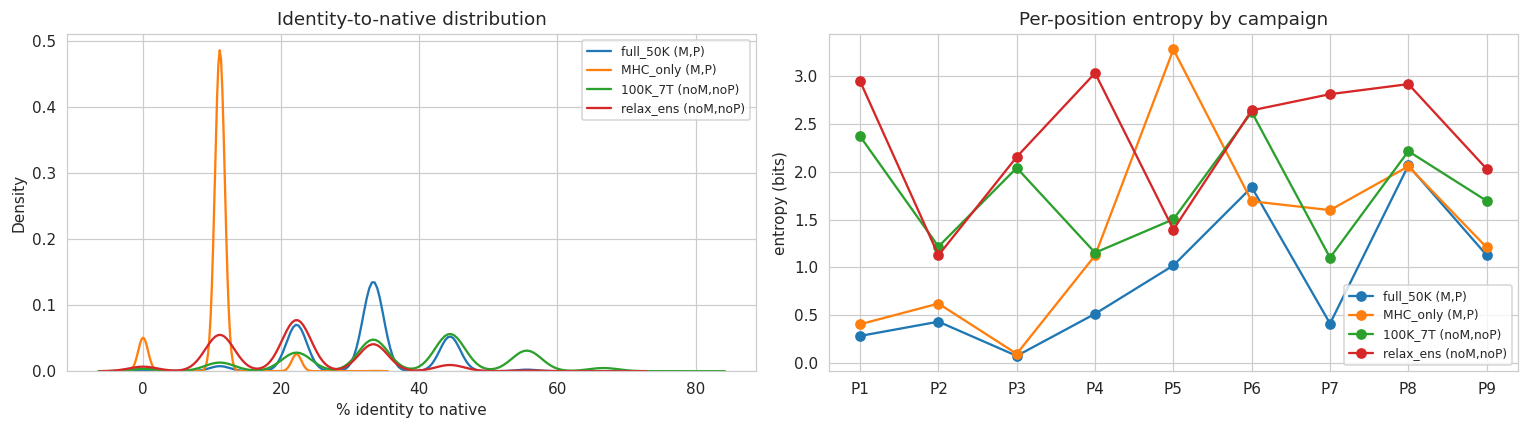

In [6]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
for lab in labels:
    P=np.array([list(s) for s in C[lab]]); ident=(P==nat).mean(1)*100
    sns.kdeplot(ident,ax=ax[0],label=lab.replace(chr(10),' '),fill=False,bw_adjust=1.5)
ax[0].set_xlabel("% identity to native"); ax[0].set_title("Identity-to-native distribution"); ax[0].legend(fontsize=8)
eps=1e-12
for lab in labels:
    f=freq_matrix(C[lab],L); ent=-(f*np.log2(f+eps)).sum(1).values
    ax[1].plot(range(L),ent,marker="o",label=lab.replace(chr(10),' '))
ax[1].set_xticks(range(L)); ax[1].set_xticklabels([f"P{i+1}" for i in range(L)])
ax[1].set_ylabel("entropy (bits)"); ax[1].set_title("Per-position entropy by campaign"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"cmp_identity_entropy.png",bbox_inches="tight"); plt.show()

## 6. Amino-acid composition (watch Met & Pro collapse with constraints)

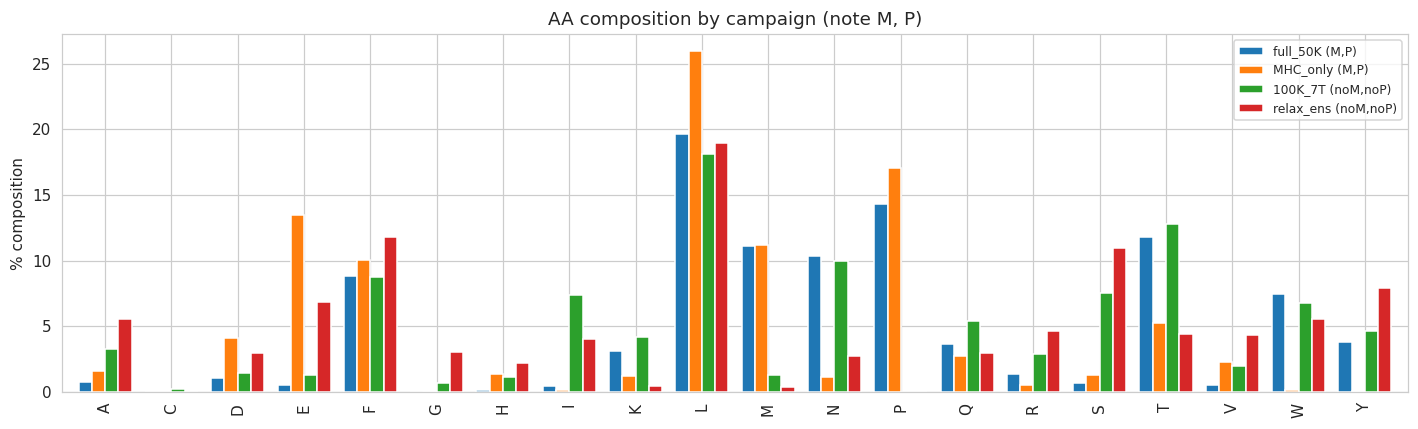

Proline % : {'full_50K (M,P)': np.float64(14.35), 'MHC_only (M,P)': np.float64(17.07), '100K_7T (noM,noP)': np.float64(0.0), 'relax_ens (noM,noP)': np.float64(0.0)}
Met %     : {'full_50K (M,P)': np.float64(11.14), 'MHC_only (M,P)': np.float64(11.2), '100K_7T (noM,noP)': np.float64(1.3), 'relax_ens (noM,noP)': np.float64(0.41)}


In [7]:
comp={}
for lab in labels:
    allc=np.array([c for s in C[lab] for c in s])
    comp[lab.replace(chr(10),' ')]=pd.Series(allc).value_counts(normalize=True).reindex(AA).fillna(0)*100
cdf=pd.DataFrame(comp)
fig,ax=plt.subplots(figsize=(13,4)); cdf.plot(kind="bar",ax=ax,width=0.8)
ax.set_ylabel("% composition"); ax.set_title("AA composition by campaign (note M, P)")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIG/"cmp_aa_comp.png",bbox_inches="tight"); plt.show()
print("Proline % :", {k:round(cdf.loc['P',k],2) for k in cdf.columns})
print("Met %     :", {k:round(cdf.loc['M',k],2) for k in cdf.columns})

## 7. RFdiffusion peptides (8–11mer, no-M/no-P)

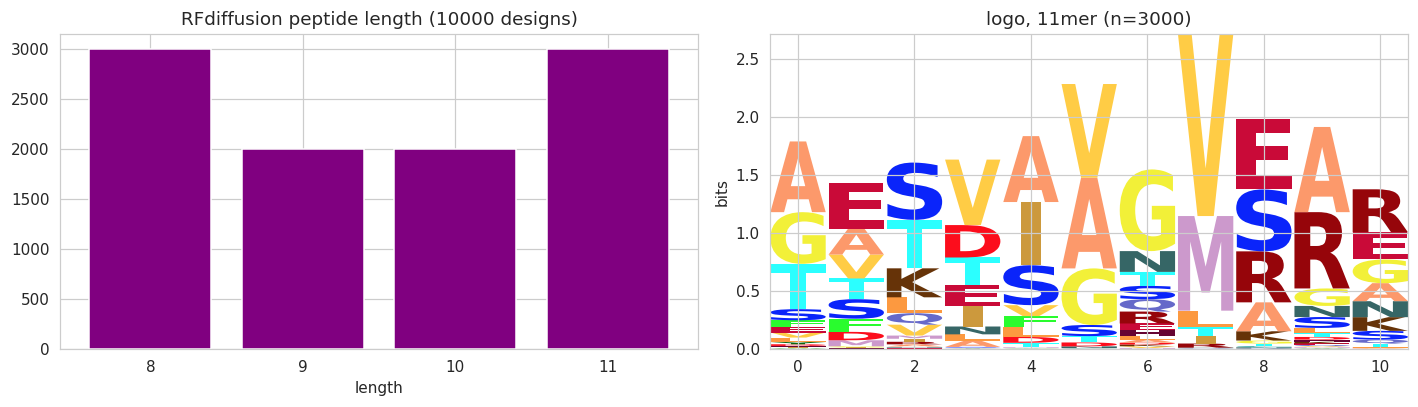

In [8]:
rf=[r["peptide"] for r in load_many(sorted(glob.glob(str(ROOT/'outputs/rfdiff_campaign/seqs/*.fa'))))]
rf=[s for s in rf if 8<=len(s)<=11]
if not rf:
    print("RFdiffusion peptide-MPNN not finished yet — re-run later.")
else:
    from collections import Counter
    lc=Counter(len(s) for s in rf)
    fig,ax=plt.subplots(1,2,figsize=(13,3.8))
    ax[0].bar([str(k) for k in sorted(lc)],[lc[k] for k in sorted(lc)],color="purple")
    ax[0].set_title(f"RFdiffusion peptide length ({len(rf)} designs)"); ax[0].set_xlabel("length")
    # logo for the most common length
    Lc=max(lc,key=lc.get); seqs=[s for s in rf if len(s)==Lc]
    f=freq_matrix(seqs,Lc); import logomaker
    info=logomaker.transform_matrix(f.copy(),from_type="probability",to_type="information")
    logomaker.Logo(info,ax=ax[1],color_scheme="skylign_protein"); ax[1].set_title(f"logo, {Lc}mer (n={len(seqs)})"); ax[1].set_ylabel("bits")
    plt.tight_layout(); plt.savefig(FIG/"cmp_rfdiff.png",bbox_inches="tight"); plt.show()

## 8. Dataset recovery panel (22 pMHC-TCR structures)

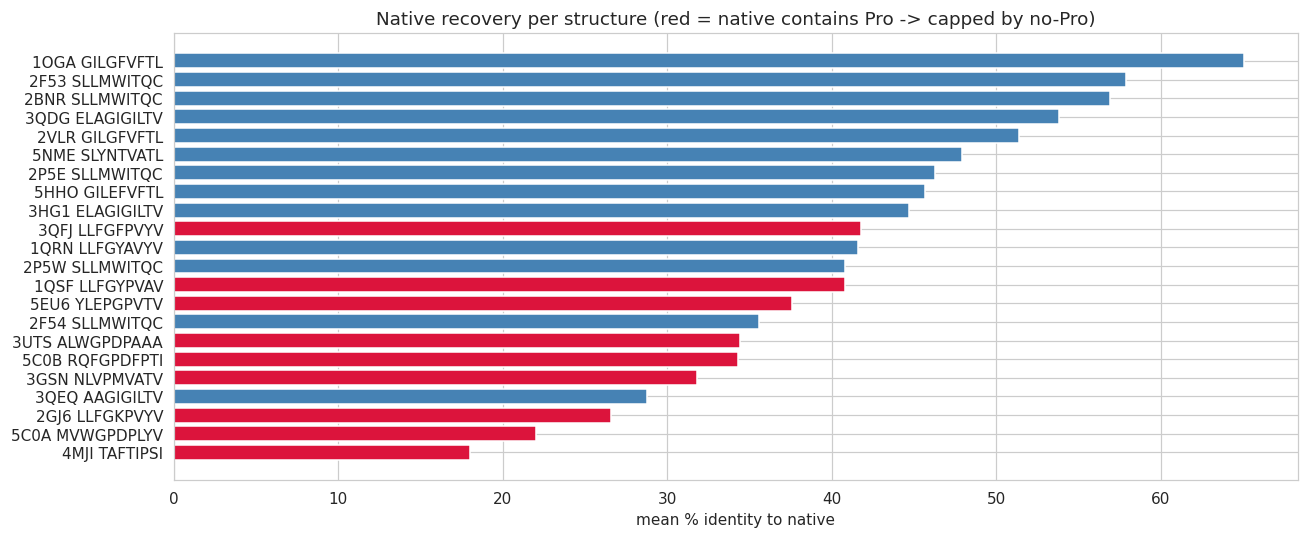

dataset mean recovery: 41.1% over 22 structures


,pdb,native,mean_id,max_id,best_design,has_Pro_native
21,4MJI,TAFTIPSI,18.0,37.5,GAFALASS,True
20,5C0A,MVWGPDPLYV,22.0,30.0,AVFGIAFLNL,True
19,2GJ6,LLFGKPVYV,26.6,44.4,LLFGFARRL,True
18,3QEQ,AAGIGILTV,28.8,55.6,AFGEGELAV,False
17,3GSN,NLVPMVATV,31.8,33.3,SLMAQEATL,True
16,5C0B,RQFGPDFPTI,34.3,60.0,RLFGFDFMTL,True
15,3UTS,ALWGPDPAAA,34.4,50.0,ALFGWDLAQL,True
14,2F54,SLLMWITQC,35.6,66.7,SLLDWIAQL,False
13,5EU6,YLEPGPVTV,37.6,44.4,RLYGGAVTL,True
11,1QSF,LLFGYPVAV,40.8,66.7,LLFGWAVTV,True


In [9]:
rp=ROOT/"outputs/dataset_protocol/recovery.csv"
if not rp.exists():
    print("dataset recovery not ready yet — re-run later.")
else:
    rec=pd.read_csv(rp).sort_values("mean_id")
    fig,ax=plt.subplots(figsize=(12,5))
    colors=["crimson" if hp else "steelblue" for hp in rec["has_Pro_native"]]
    ax.barh(rec["pdb"]+" "+rec["native"],rec["mean_id"],color=colors)
    ax.set_xlabel("mean % identity to native"); ax.set_title("Native recovery per structure (red = native contains Pro -> capped by no-Pro)")
    plt.tight_layout(); plt.savefig(FIG/"cmp_dataset_recovery.png",bbox_inches="tight"); plt.show()
    print("dataset mean recovery: %.1f%% over %d structures"%(rec.mean_id.mean(),len(rec)))
    display(rec[["pdb","native","mean_id","max_id","best_design","has_Pro_native"]])